In [ ]:
import matplotlib.pyplot as plt
import wiemip_registry as wr

forcing = "ukesm"


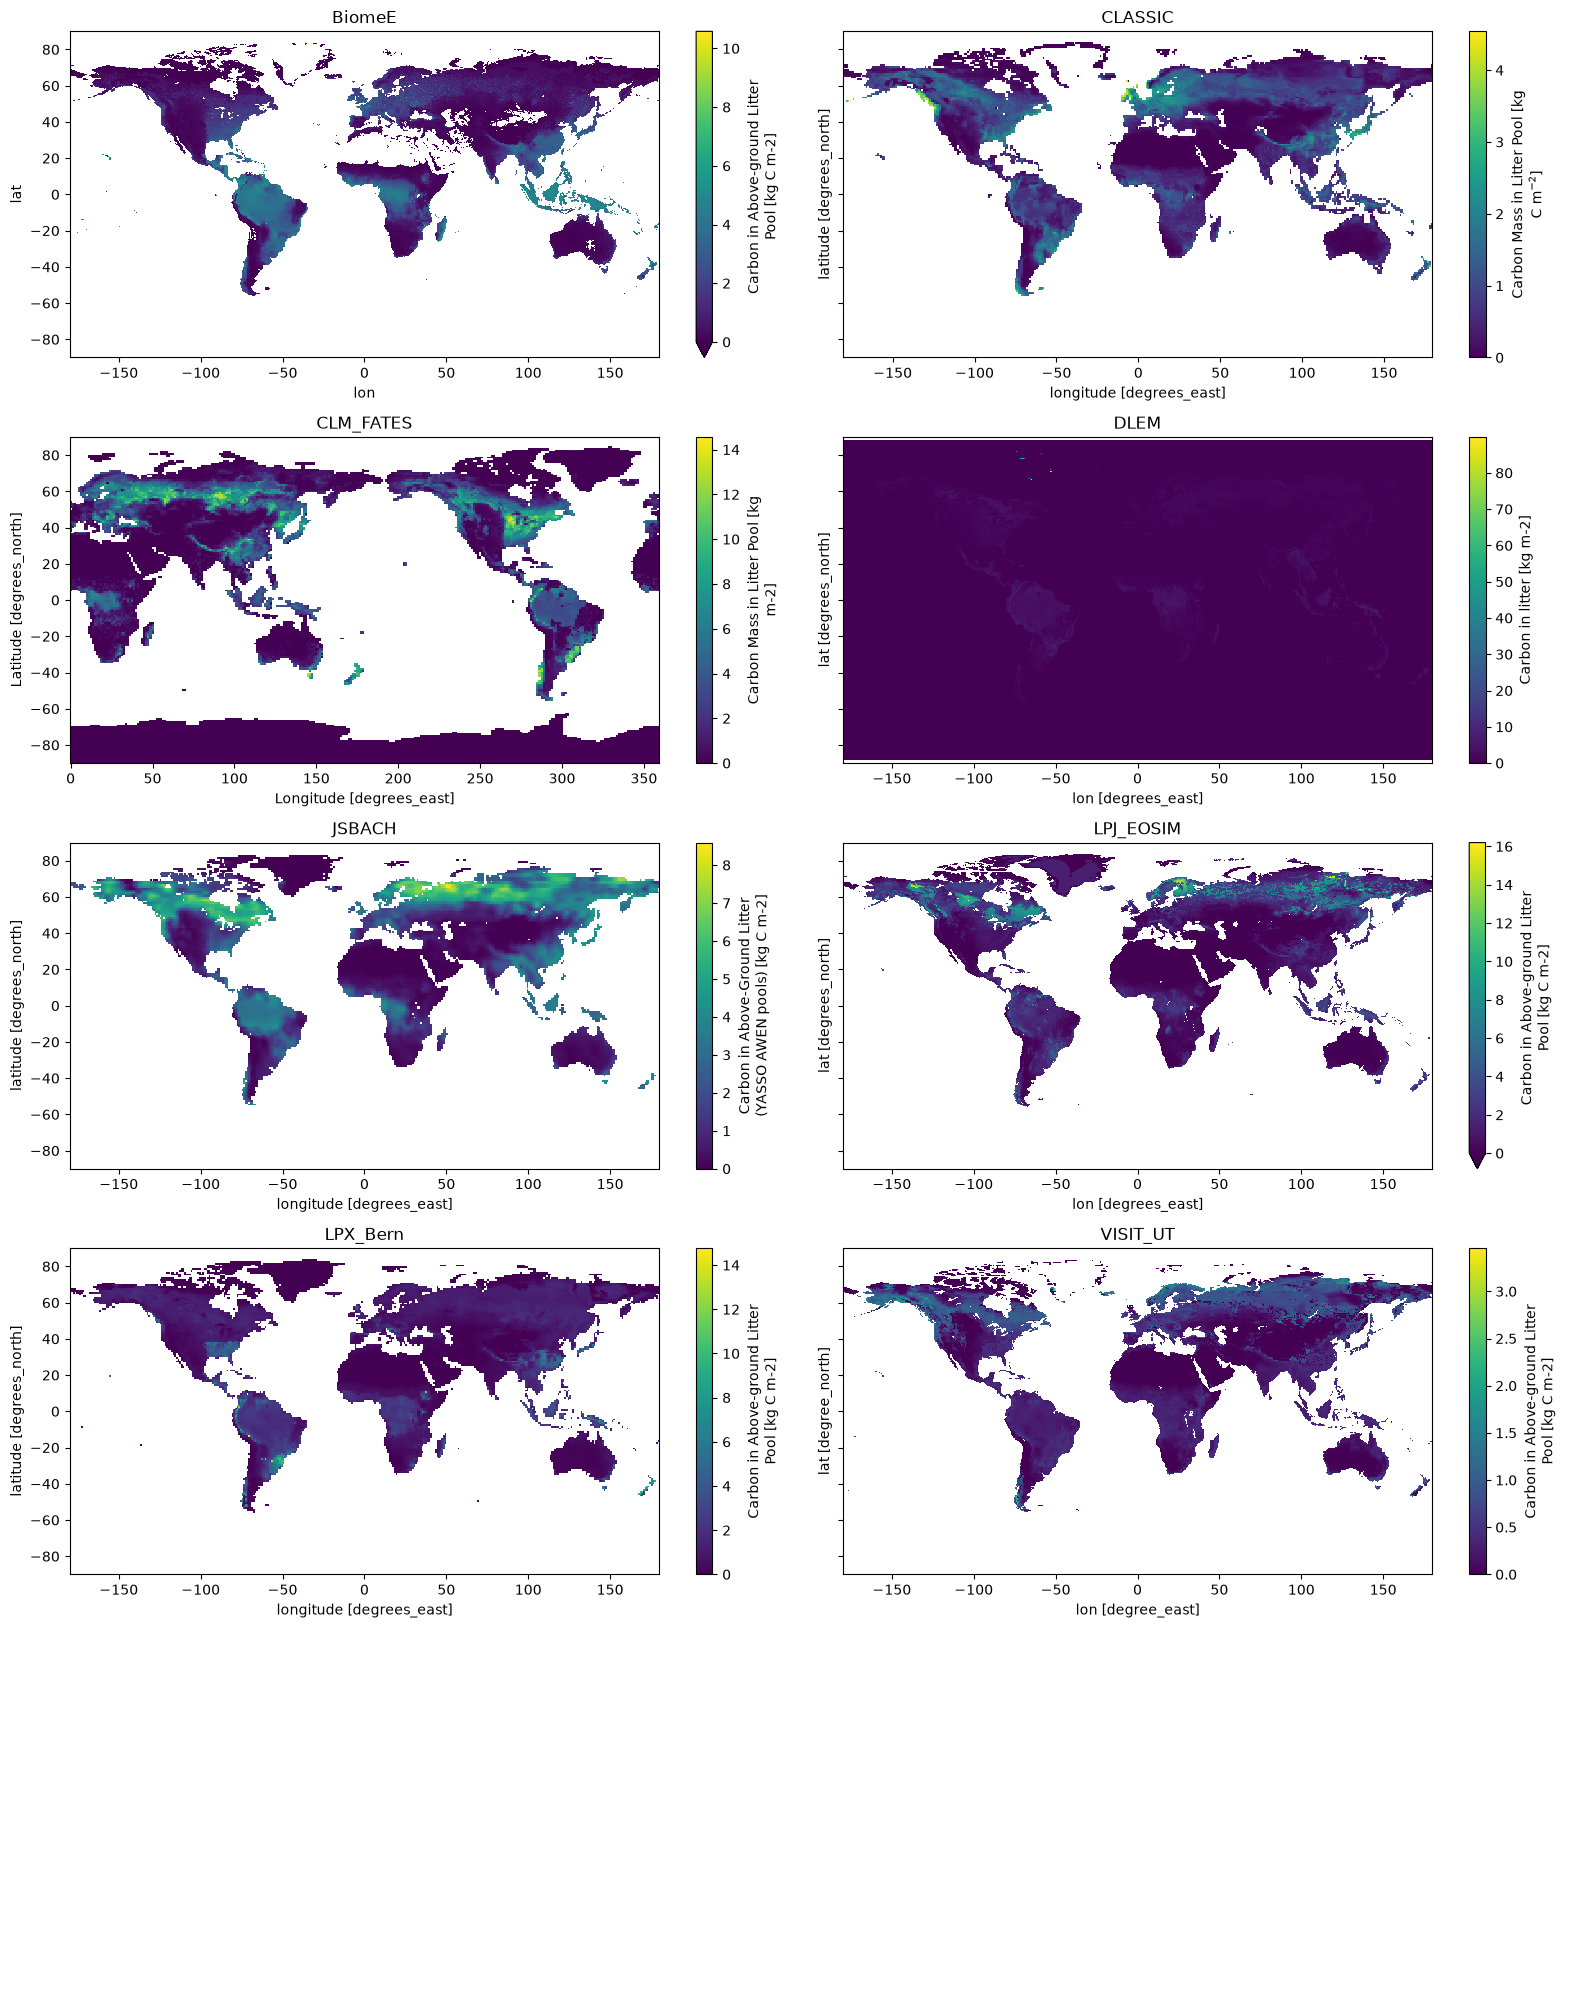

In [2]:
models = list(wr.models)
nrow = (len(models) + 1) // 2
fig, axes = plt.subplots(nrow, 2, figsize=(16, 4 * nrow), sharex=False, sharey=True)
axes = axes.ravel()

i = 0
for m in models:
    total = None
    for v in ["cLitter"]:
        f = wr.retrieve_one_pct_variable(
            model=m, forcing=forcing, simulation="cou", factorial="baseline", variable=v
        )
        if not f.exists():
            continue
        da = f.read().isel(time=0)
        total = da if total is None else total + da

    if total is None:
        continue
    total.plot(ax=axes[i], vmin=0)
    axes[i].set_title(m)
    i += 1

for ax in axes[i:]:
    ax.axis("off")

fig.tight_layout()
plt.show()


Note - the LPJ-EOSIM team retuned the model to get close to baseline stocks and fluxes, which could be responsible for the extreme vegetation
carbon growth displayed below

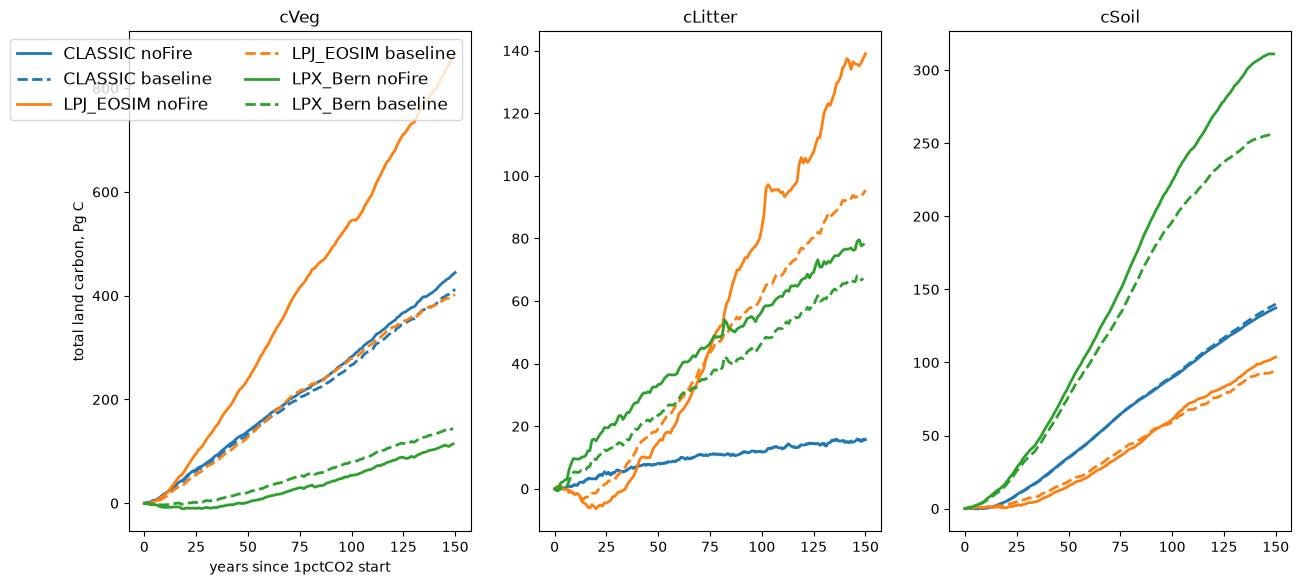

In [10]:
fig, ax = plt.subplots(figsize=(15, 6.5), ncols=3)
for m in models:
    if m == 'VISIT_UT':
        continue
    total = None
    for i, v in enumerate(["cVeg", "cLitter", "cSoil"]):
        f = wr.retrieve_one_pct_variable(
            model=m, forcing=forcing, simulation="cou", factorial="noFire", variable=v
        )
        if not f.exists():
            continue
        else:
            f2 = wr.retrieve_one_pct_variable(
                model=m, forcing=forcing, simulation="cou", factorial="baseline", variable=v
            )
        s = f.latitudinal_sum()
        s2 = f2.latitudinal_sum()
        c = ax[i].plot(s.values-s.values[0], lw=2, label=m + " noFire")[0].get_color()
        ax[i].plot(s2.values-s2.values[0], '--', lw=2, label=m + " baseline",c=c)
        ax[i].set_title(v)

ax[0].set_xlabel("years since 1pctCO2 start")
ax[0].set_ylabel("total land carbon, Pg C")
ax[0].legend(fontsize=12, ncol=2)
plt.show()
